<div align="center">
  <img src="fotos/logo_utem.png" alt="Logo UTEM" width="120" style="max-height:140px; height:auto;"/>
  <br><br>

  <p style="margin:2px 0; font-size:16px; font-weight:400; text-shadow:none;">UNIVERSIDAD TECNOLOGICA METROPOLITANA</p>
  <p style="margin:2px 0; font-size:14px; font-weight:400; text-shadow:none;">INGENIERIA CIVIL EN CIENCIA DE DATOS</p>
  <p style="margin:2px 0; font-size:14px; font-weight:400; text-shadow:none;">INFB8090 - COMPUTACION PARALELA Y DISTRIBUIDA</p>

  <br><br>
  <h2 style="margin:0;">Prueba 1</h2>
  <br>
  <h1 style="margin:0;"><i>Parte II Grupal</i></h1>

  <br><br>
  <p style="margin:2px 0;">Profesor: Michael Miranda Sandoval</p>
  <p style="margin:2px 0;">Integrante: Diego Silva Madariaga/Pablo Ibañez</p>
  <p style="margin:2px 0;">Fecha: 24/05 de 2026</p>
</div>

## Resumen ejecutivo

Se presenta el diseño, implementación y análisis de rendimiento de tres estrategias de paralelización aplicadas a problemas de cómputo intensivo visto durante la prueba 1. El problema 1 implementa normalización masiva de datos con OpenMP en C++, alcanzando un speedup de 8.96x con 16 hilos. El problema 2 construye un pipeline concurrente de procesamiento de logs en Python, comparando threading, multiprocessing y un enfoque híbrido con asyncio, donde multiprocessing logra el mejor resultado con 2.68x. El problema 3 resuelve una búsqueda de similitud Top-K por bloques usando memoria compartida entre procesos, obteniendo un speedup de 3.31x con 4 workers. En los tres casos el cuello de botella común es el ancho de banda de memoria, no la cantidad de núcleos disponibles.

Los tres códigos se encuentran en prueba_1_computacion_paralela/parte_2_grupal/. El problema 1 está en codigo_openmp/normalizacion.cpp, se compila con el Makefile usando el compilador w64devkit provisto por el profesor y se ejecuta como programa independiente, generando los resultados en anexos_benchmark/. El problema 2 se ejecuta desde consola con python pipeline_ejercicio2.py dentro de la carpeta parte_2_grupal/, y los resultados quedan guardados en anexos_benchmark/ para que el notebook los lea directamente.El problema 3 esta en similitud_ejercicio3.py y se ejecutan desde el notebook con %run.

- Para el ejercicio 1, desde VSCode abre el archivo codigo_openmp/normalizacion.cpp y presiona Ctrl+Shift+B. Esto compila y ejecuta automáticamente el programa, guardando los resultados en anexos_benchmark/.
- Para el ejercicio 2, abre una consola, navega a la carpeta con cd D:\U\COMPUTACION_PARALELA_DISTRIBUIDA\prueba_1_computacion_paralela\parte_2_grupal, activa el entorno con conda activate lab1_paralela y ejecuta python pipeline_ejercicio2.py. Los resultados quedan guardados en anexos_benchmark/.
Una vez ejecutados ambos, abrir el notebook Informe.ipynb con el entorno lab1_paralela activo y correr todas las celdas en orden.

El compilador w64devkit no está incluido en el repositorio. Para compilar el ejercicio 1, descargar w64devkit desde el enlace provisto por el profesor y colocarlo en la carpeta prueba_1_computacion_paralela/parte_2_grupal/codigo_openmp/w64devkit/. Una vez ubicado ahí, abrir el archivo normalizacion.cpp en VSCode y presionar Ctrl+Shift+B para compilar y ejecutar.

Para reproducir los problemas 2 y 3 se requiere el entorno lab1_paralela, que se crea con conda env create -f Tareas/environment.yml. El entorno incluye Python 3.11, NumPy, Matplotlib y Pandas.
Los benchmarks se realizaron en un equipo con procesador AMD Ryzen 7 5700X (8 núcleos, 16 hilos), GPU NVIDIA RTX 4060, 16 GB de RAM, almacenamiento SSD M.2 y Windows 11.

El PDF del anteproyecto se encuentra en la carpeta raíz COMPUTACION_PARALELA_DISTRIBUIDA/, no en subcarpetas.

<h2 style="text-align:center; margin:0;"><i>Problema N°1</i></h2>
<br>
<h2 style="text-align:center; margin:0;"><i>Normalización masiva con OpenMP en C/C++</i></h2>

#### Problema

Se dispone de una matriz X de 50 millones de filas y 16 columnas, donde cada fila representa una observación y cada columna una variable numérica. Existen valores faltantes representados como NaN distribuidos aleatoriamente. El objetivo es calcular por columna la media, varianza, cantidad de valores válidos, valores atípicos con |z| > 3, y producir la matriz normalizada Z. El volumen de datos hace inviable un enfoque serial eficiente por lo que se requiere paralelismo explícito con OpenMP en C/C++.

#### Comparacion de estrategias

Estrategia A: Usar schedule(dynamic) argumentando que los NaN generan desbalance entre filas, y reduction para la sincronización de acumuladores.

Estrategia B: Partir la matriz por bloques de filas para aprovechar la caché, ya que con d=16 cada fila ocupa exactamente 64 bytes (una línea de caché). Usa reduction 
para eliminar condiciones de carrera y descarta critical por serializar el loop. Identifica el ancho de banda de memoria como cuello de botella principal.

Se selecciono la segunda estrategia por que el uso de schedule(dynamic) en A no está justificado porque el cómputo por fila es uniforme, saltar NaN no introduce desbalance significativo y agrega overhead innecesario. La estrategia B es más precisa técnicamente al identificar el cuello de botella real y justificar explícitamente las decisiones de particionamiento y sincronización.

#### Uso de OpenMP

Se implementa la normalización en 3 pasadas secuenciales sobre la matriz, cada una paralelizada con #pragma omp parallel for para dividir el rango de filas entre los hilos disponibles, de modo que cada hilo procesa un bloque siguiente de filas. Dentro de cada iteración el hilo accede a las columnas de su fila y acumula valores en copias locales de los arreglos suma, suma2 y count, generadas automáticamente por reduction. OpenMP crea una copia privada de cada arreglo por hilo, los hilos acumulan de forma independiente sin interferir entre sí, y al finalizar el loop suma todas las copias en el arreglo original. Esto equivale a arreglos privados por hilo consolidados al final, pero de forma automática y segura.

Las 3 pasadas son necesarias porque la varianza depende de la media completa, pues calcularlas en una sola pasada introduciría error numérico. El particionamiento usa schedule(static) ya que el trabajo por fila es uniforme descartando schedule(dynamic) que agrega overhead sin beneficio real.

El uso de #pragma omp critical en lugar de reduction habría sido una mala decisión pues con 50 millones de iteraciones, cada hilo tendría que esperar su turno para actualizar suma[j], bloqueándose la mayor parte del tiempo y ejecutándose en la práctica de forma serial. El overhead de adquirir y liberar el lock en cada iteración destruiría completamente el beneficio del paralelismo, resultando en tiempos incluso peores que la versión serial.

In [7]:
import subprocess
subprocess.run(["pip", "install", "pandas", "matplotlib"], check=True)

CompletedProcess(args=['pip', 'install', 'pandas', 'matplotlib'], returncode=0)

### Los experimentos se ejecutaron con OMP_NUM_THREADS = 1, 2, 4, 8 y 16 sobre la matriz de 50 millones de filas × 16 columnas

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("anexos_benchmark/resultados1.csv")
print(df)

   hilos  tiempo  speedup  eficiencia
0      1  18.813   1.0000      1.0000
1      2  10.404   1.8082      0.9041
2      4   5.076   3.7063      0.9266
3      8   2.771   6.7892      0.8487
4     16   2.099   8.9628      0.5602


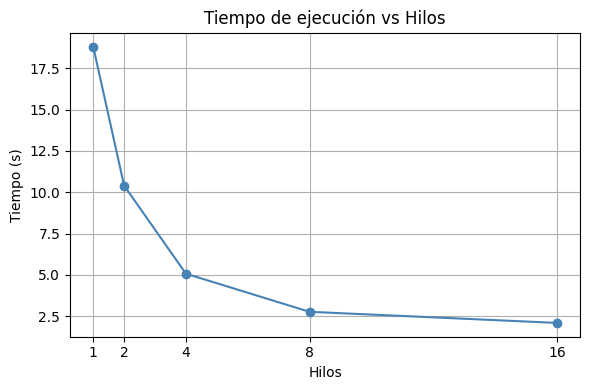

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(df["hilos"], df["tiempo"], marker="o", color="steelblue")
plt.title("Tiempo de ejecución vs Hilos")
plt.xlabel("Hilos")
plt.ylabel("Tiempo (s)")
plt.xticks(df["hilos"])
plt.grid(True)
plt.tight_layout()
plt.savefig("anexos_benchmark/grafico_tiempo1.png", dpi=150)
plt.show()

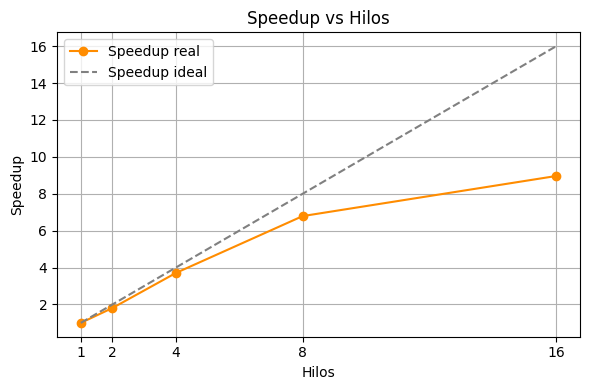

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(df["hilos"], df["speedup"], marker="o", color="darkorange", label="Speedup real")
plt.plot(df["hilos"], df["hilos"], linestyle="--", color="gray", label="Speedup ideal")
plt.title("Speedup vs Hilos")
plt.xlabel("Hilos")
plt.ylabel("Speedup")
plt.xticks(df["hilos"])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("anexos_benchmark/grafico_speedup1.png", dpi=150)
plt.show()

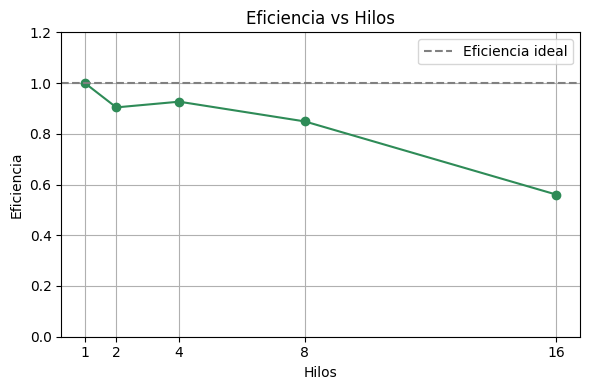

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(df["hilos"], df["eficiencia"], marker="o", color="seagreen")
plt.axhline(y=1.0, linestyle="--", color="gray", label="Eficiencia ideal")
plt.title("Eficiencia vs Hilos")
plt.xlabel("Hilos")
plt.ylabel("Eficiencia")
plt.xticks(df["hilos"])
plt.ylim(0, 1.2)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("anexos_benchmark/grafico_eficiencia1.png", dpi=150)
plt.show()

El speedup escala bien hasta 8 hilos, con eficiencias sobre 0.85. Sin embargo al pasar a 16 hilos la eficiencia cae bruscamente a 0.56, lo que significa que los 8 hilos adicionales solo aportan un 2.17x extra de speedup en lugar del 2x esperado. Esto confirma lo planteado en la estrategia: el cuello de botella no es la capacidad de cómputo de la CPU sino el ancho de banda de memoria. La operación lee ~3.2 GB de datos en 3 pasadas, saturando el bus de memoria antes de que la CPU quede sin trabajo. Con 16 hilos lógicos activos simultáneamente compitiendo por el mismo bus, los hilos adicionales pasan más tiempo esperando datos que procesando. Esto explica por qué el speedup real nunca alcanza el ideal lineal y por qué la eficiencia cae progresivamente al aumentar los hilos.

¿Por qué no escala linealmente?. Al ser un problema memory-bound agregar más hilos no aumenta el ancho de banda de memoria disponible. Según la ley de Amdahl si la fracción paralela está limitada por memoria y no por cómputo el speedup tiene un techo que no se puede superar simplemente aumentando hilos. En este caso ese techo se hace evidente al pasar de 8 a 16 hilos, donde la eficiencia cae de 0.85 a 0.56.

<h2 style="text-align:center; margin:0;"><i>Problema N°2</i></h2>
<br>
<h2 style="text-align:center; margin:0;"><i>Pipeline concurrente de procesamiento de logs en Python</i></h2> 

#### Diagnostico del pipeline

Se dispone de 2 GB de logs comprimidos donde cada línea contiene identificador de usuario, timestamp, endpoint, latencia y código de respuesta. El objetivo es construir ventanas de 15 minutos con métricas agregadas por usuario y endpoint. El pipeline tiene tres etapas secuenciales: lectura y descompresión, parseo y limpieza, y agregación por ventanas temporales.

El problema principal es que cada etapa tiene una naturaleza distinta en términos de uso de recursos. 

- La lectura y descompresión es I/O-bound pues el proceso pasa la mayor parte del tiempo esperando datos del disco o de la red sin hacer cómputo intensivo. 

- El parseo y limpieza es CPU-bound, pues transformar cada línea de texto en campos estructurados, validar formatos y descartar registros inválidos requiere cómputo activo por cada línea procesada y con 2 GB de logs comprimidos el volumen es considerable. 

- La agregación por ventanas temporales es nuevamente I/O-bound en términos de escritura de resultados pero requiere mantener estado consistente entre registros del mismo usuario y ventana de tiempo.

Usar solo threading no resuelve el cuello de botella del parseo por el GIL, y usar solo multiprocessing es ineficiente para las etapas de lectura donde los procesos quedarían bloqueados esperando I/O sin aprovechar el paralelismo real.

#### Comparacion de estrategias

Estrategia A: Usar multiprocessing puro donde cada proceso lee, parsea y preagrega en sus propios bloques del archivo. Identificando correctamente que el GIL impide paralelizar el parseo CPU-bound con hilos. El punto más relevante es que si los procesos envían los logs crudos entre sí en lugar de las métricas ya resumidas, el sistema colapsa por el volumen de copias de memoria entre procesos.

Estrategia B: Un pipeline mixto donde asyncio maneja las etapas I/O-bound de lectura y descompresión y multiprocessing maneja las etapas CPU-bound parseo y limpieza. La agregación final es nuevamente I/O-bound. Se define explícitamente qué herramienta usar en cada etapa según la naturaleza del trabajo en lugar de aplicar una sola herramienta a todo el pipeline.

La estrategia B es la mejor ya que el multiprocessing puro de la estrategia A es correcto para el parseo pero ineficiente para la lectura, lanzar procesos completos para esperar I/O desperdicia recursos y aumenta el overhead de arranque. La estrategia B es más precisa al separar las herramientas según el tipo de carga, asyncio para concurrencia I/O sin overhead de procesos, y multiprocessing para paralelismo real en la parte CPU-bound evitando el GIL.

#### Comparación de herramientas Python

- Threading y ThreadPoolExecutor permiten ejecutar múltiples hilos dentro del mismo proceso, pero el GIL de Python impide que más de un hilo ejecute código Python al mismo tiempo. Esto lo hace inútil para tareas CPU-bound como el parseo, aunque funciona para I/O-bound simple donde los hilos pasan la mayor parte del tiempo esperando y no compitiendo por el GIL.

- Multiprocessing y ProcessPoolExecutor crean procesos independientes con su propio intérprete Python, evitando el GIL completamente y logrando paralelismo real. Es la herramienta correcta para tareas CPU-bound. Su desventaja es el alto overhead: arrancar procesos es costoso y comunicar datos entre ellos requiere serialización, lo que puede convertirse en un cuello de botella si se envían grandes volúmenes de datos crudos entre procesos.

- Asyncio no genera paralelismo real sino concurrencia cooperativa, un solo hilo alterna entre tareas cuando alguna está esperando I/O. No resuelve el GIL pero es muy eficiente para manejar muchas operaciones I/O simultáneas con overhead mínimo, sin el costo de crear procesos o hilos.

#### Estrategia final

Se implementa un pipeline híbrido asyncio + multiprocessing. asyncio coordina la distribución de chunks al pool de procesos, que permite procesar múltiples chunks del archivo de forma concurrente sin crear procesos adicionales. El parseo y limpieza se delega a un ProcessPoolExecutor, donde cada worker recibe un chunk de líneas ya descomprimidas, las parsea y preagrega las métricas por usuario y endpoint dentro de su ventana temporal. La agregación final consolida los resultados parciales de cada worker en el proceso principal.

El GIL no limita esta estrategia porque la única parte donde importa el paralelismo real es el parseo, que corre en procesos independientes fuera del GIL. El overhead se controla enviando entre procesos solo las métricas preagregadas y no los logs crudos, cada worker reduce su chunk antes de comunicar resultados, minimizando el volumen de datos serializados. El particionamiento se hace por bloques de tamaño fijo del archivo comprimido, asignando un chunk por worker para evitar desbalance. La agregación parcial dentro de cada worker garantiza que no hay condiciones de carrera, ya que cada proceso trabaja sobre su propio conjunto de datos sin compartir estado.

Para medir correctamente el rendimiento del pipeline se deben evitar cuatro errores comunes al diseñar el benchmark. Primero, medir el pipeline completo de principio a fin, no solo una etapa aislada, ya que las etapas se afectan mutuamente. Segundo, incluir una ejecución de warm-up antes de registrar tiempos para descartar el overhead de inicialización del pool de procesos y carga de librerías. Tercero, mantener el tamaño de chunk fijo entre todas las ejecuciones comparadas, ya que cambiarlo altera el balance entre overhead y paralelismo. Cuarto, comparar siempre con la misma carga de datos.

Se usaran 4 workers,considerando que se dispone de 16 núcleos. Con 4 workers se balancea el paralelismo real contra el overhead de IPC, aumentar a 8 o 16 workers no mejoraría significativamente dado que el cuello de botella es la serialización entre procesos, no la capacidad de cómputo.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("anexos_benchmark/resultados2.csv")
print(df)

                      config   tiempo  speedup  eficiencia
0                 Secuencial  47.2310   1.0000      1.0000
1                  Threading  47.0617   1.0036      0.2509
2            Multiprocessing  17.6004   2.6835      0.6709
3  Hibrido asyncio+multiproc  17.4757   2.7027      0.6757


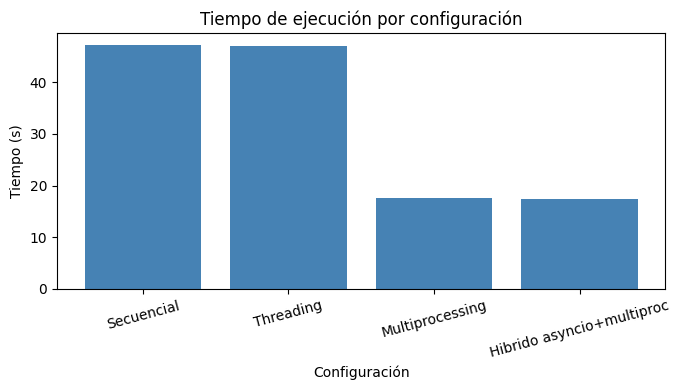

In [16]:
plt.figure(figsize=(7,4))
plt.bar(df["config"], df["tiempo"], color="steelblue")
plt.title("Tiempo de ejecución por configuración")
plt.xlabel("Configuración")
plt.ylabel("Tiempo (s)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("anexos_benchmark/grafico2_tiempo.png", dpi=150)
plt.show()

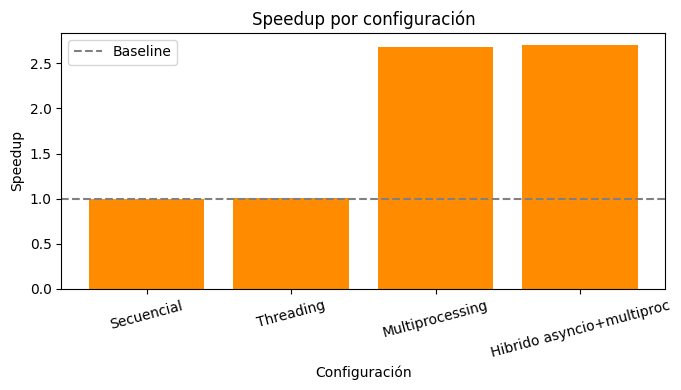

In [17]:
plt.figure(figsize=(7,4))
plt.bar(df["config"], df["speedup"], color="darkorange")
plt.axhline(y=1.0, linestyle="--", color="gray", label="Baseline")
plt.title("Speedup por configuración")
plt.xlabel("Configuración")
plt.ylabel("Speedup")
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.savefig("anexos_benchmark/grafico2_speedup.png", dpi=150)
plt.show()

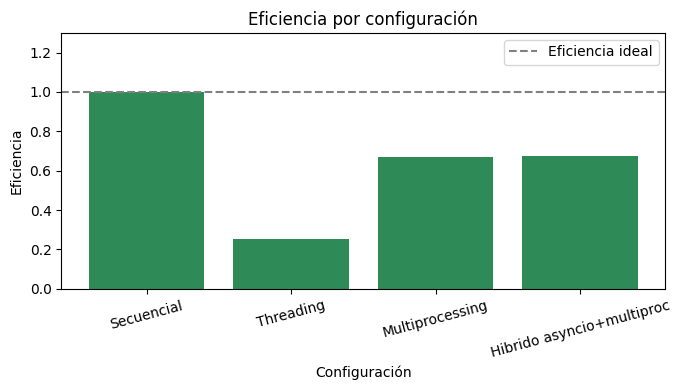

In [18]:
plt.figure(figsize=(7,4))
plt.bar(df["config"], df["eficiencia"], color="seagreen")
plt.axhline(y=1.0, linestyle="--", color="gray", label="Eficiencia ideal")
plt.title("Eficiencia por configuración")
plt.xlabel("Configuración")
plt.ylabel("Eficiencia")
plt.xticks(rotation=15)
plt.ylim(0, 1.3)
plt.legend()
plt.tight_layout()
plt.savefig("anexos_benchmark/grafico2_eficiencia.png", dpi=150)
plt.show()

- Threading confirma empíricamente el efecto del GIL, pues con 4 hilos el tiempo es prácticamente idéntico al secuencial, demostrando que en tareas CPU-bound como el parseo de texto, los hilos no logran paralelismo real y el overhead de cambio de contexto anula cualquier beneficio.

- Multiprocessing logra un speedup de 2.68x con 4 workers, pero no alcanza el ideal de 4x. La eficiencia de 0.67 refleja el costo de serialización al pasar chunks entre procesos y el overhead, exactamente el riesgo identificado en la estrategia.

- El híbrido asyncio+multiprocessing mejora marginalmente sobre multiprocessing puro (2.70x vs 2.68x). La diferencia es pequeña porque el cuello de botella real en este pipeline es el parseo CPU-bound, no la lectura. asyncio aporta más cuando hay muchas conexiones I/O concurrentes, no cuando se lee un solo archivo secuencial.

Esto demuestra que no existe una herramienta universal, threading es suficiente para I/O puro, multiprocessing es necesario para CPU-bound, y el híbrido solo justifica su complejidad adicional cuando ambas cargas son igualmente dominantes. En este pipeline el parseo domina, por lo que multiprocessing y el híbrido convergen al mismo resultado.

<h2 style="text-align:center; margin:0;"><i>Problema N°3</i></h2>
<br>
<h2 style="text-align:center; margin:0;"><i>Búsqueda de Similitud Top-K por Bloques con Memoria Compartida</i></h2> 

El problema consiste en encontrar los 10 vectores más similares para cada uno de los 20.000 vectores de dimensión 128, usando producto punto como métrica. La restricción principal es que la matriz de similitud completa (20.000 × 20.000) no cabe en memoria, por lo que el cálculo debe hacerse por bloques.

- Estrategia A Método Halos: Dividir los vectores en bloques con bordes solapados entre bloques vecinos, para evitar perder vecinos cercanos que queden en la frontera.

- Estrategia B Bloques + Heap Top-K + Memoria Compartida: Dividir las consultas en bloques de 2.000 vectores, donde cada worker calcula el producto punto de su bloque contra la matriz completa y mantiene solo los 10 mejores resultados por vector usando argpartition.

Se eligió la estrategia B porque resuelve directamente los dos problemas del enunciado: la restricción de memoria,nunca se materializa la matriz completa de similitudes, solo bloques, y el costo computacional (el cálculo por bloques se distribuye entre workers en paralelo con ProcessPoolExecutor). La memoria compartida es la clave que permite escalar sin pagar el costo de IPC.

La solución carga la matriz de 20.000 × 128 una sola vez en un bloque de memoria compartida del sistema operativo (shared_memory), de modo que todos los workers acceden a ella sin copias. Luego divide las consultas en bloques de 2.000 filas y distribuye cada bloque a un worker distinto usando ProcessPoolExecutor, eludiendo el GIL con multiprocesamiento real.
Cada worker calcula el producto punto de su bloque contra la matriz completa mediante rutinas BLAS de NumPy, y extrae los 10 mejores resultados con np.argpartition en O(N), sin ordenar toda la fila. Solo esos 10 se ordenan localmente. El resultado final se ensambla en el proceso principal sin condiciones de carrera, ya que cada worker escribe en un rango distinto del arreglo de resultados.

In [6]:
%run similitud_ejercicio3.py

Generando dataset...

Matriz compartida en RAM: 9.77 MB
----------------------------------------------------------------------
Workers    | Tiempo (s)   | Speedup    | Eficiencia
----------------------------------------------------------------------
1          | 4.9974       | 1.0000     | 1.0000    
2          | 1.9133       | 2.6119     | 1.3059    
3          | 1.7383       | 2.8749     | 0.9583    
4          | 1.5107       | 3.3080     | 0.8270    
8          | 1.5165       | 3.2953     | 0.4119    

Resultados guardados en anexos_benchmark/resultados3.csv


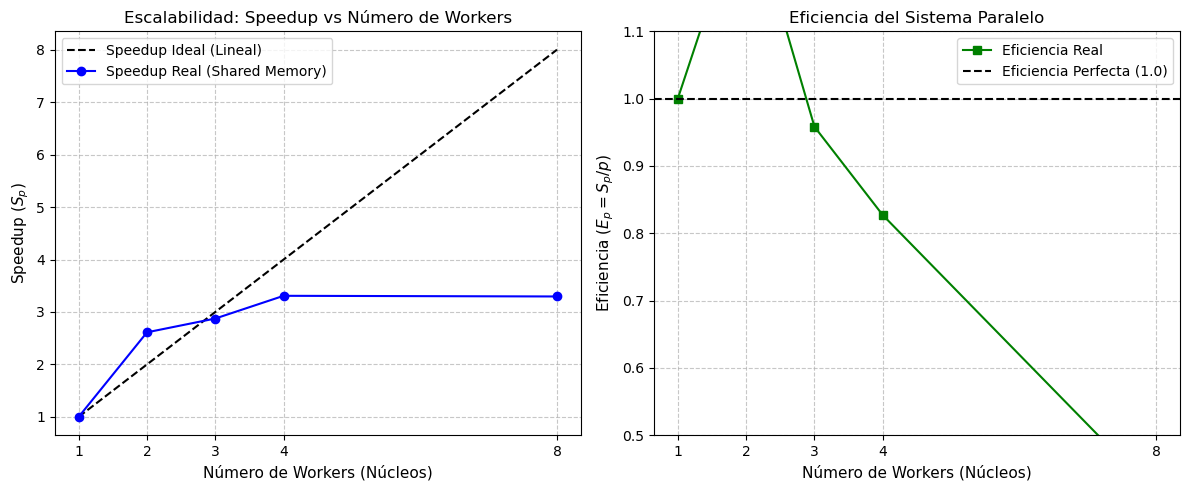

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("anexos_benchmark/resultados3.csv")

workers = df["workers"].values
speedup_real = df["speedup"].values
eficiencia = df["eficiencia"].values
speedup_ideal = workers.astype(float)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(workers, speedup_ideal, 'k--', label='Speedup Ideal (Lineal)')
plt.plot(workers, speedup_real, 'b-o', label='Speedup Real (Shared Memory)')
plt.title('Escalabilidad: Speedup vs Número de Workers', fontsize=12)
plt.xlabel('Número de Workers (Núcleos)', fontsize=11)
plt.ylabel('Speedup ($S_p$)', fontsize=11)
plt.xticks(workers)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(workers, eficiencia, 'g-s', label='Eficiencia Real')
plt.axhline(y=1.0, color='k', linestyle='--', label='Eficiencia Perfecta (1.0)')
plt.title('Eficiencia del Sistema Paralelo', fontsize=12)
plt.xlabel('Número de Workers (Núcleos)', fontsize=11)
plt.ylabel('Eficiencia ($E_p = S_p / p$)', fontsize=11)
plt.ylim(0.5, 1.1)
plt.xticks(workers)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('anexos_benchmark/benchmark_ejercicio3.png', dpi=300)
plt.show()

Con 1 worker el tiempo base es 4.99s. Al pasar a 2 workers el speedup es 2.61, lo que da una eficiencia de 1.31 — superlineal. Esto no es un error, sino un efecto de caché: con un solo worker la matriz completa no cabe en L3 y hay muchos cache misses, pero al dividir el trabajo en 2 bloques cada proceso trabaja con menos datos y aprovecha mejor la caché, acelerando más de lo esperado.

De 3 a 4 workers el speedup sigue creciendo pero más lento (2.87 y 3.31 respectivamente), con eficiencias de 0.96 y 0.83. Aquí el cuello de botella empieza a ser el ancho de banda de memoria: aunque hay más cores disponibles, todos compiten por leer la misma matriz de 9.77 MB desde RAM.

Con 8 workers el speedup se estanca en 3.30, prácticamente igual que con 4. Agregar más procesos ya no ayuda porque el bus de memoria está saturado — el problema pasa de ser CPU-bound a Memory-bound. La eficiencia cae a 0.41, lo que indica que la mitad de los workers están esperando datos y no computando.

### Limitaciones
Si el proceso principal se interrumpe antes de ejecutar shm.close() y shm.unlink(), el bloque de memoria compartida queda ocupado en el sistema operativo hasta que se reinicie la máquina. El código lo maneja con un bloque finally para reducir ese riesgo, pero no es a prueba de fallos ante un corte forzado.
La otra limitación es de escala: la estrategia funciona bien en una sola máquina, pero si el dataset creciera a cientos de millones de vectores, la memoria compartida ya no es suficiente y habría que migrar a un modelo distribuido entre múltiples nodos, usando tecnologías como MPI o Dask.

### Analisis final

Los tres ejercicios muestran un patrón común, la paralelización mejora el rendimiento, pero siempre hay un punto donde agregar más recursos deja de ayudar.

En el primer problema con OpenMP, el cuello de botella fue ancho de banda de memoria. Con 16 hilos se logra un speedup de 8.96x sobre una matriz de 50 millones de filas, pero la eficiencia cae porque todos los hilos compiten por el mismo bus de memoria al leer y escribir datos continuamente.En el problema 2 con Python el GIL hace que threading sea inútil para trabajo CPU-intensivo. Multiprocessing logra un speedup de 2.68x con 4 workers, y el híbrido asyncio+multiprocessing no mejora significativamente porque el cuello de botella real es el parseo, no la coordinación. El overhead es el factor limitante al escalar.En el ejercicio 3, la memoria compartida elimina el costo de serialización entre procesos y permite un speedup superlineal con 2 workers por efecto de caché. pero, a partir de 4 workers el speedup se estanca en ~3.3x porque el ancho de banda de memoria vuelve a ser el límite.

En los tres casos, el diseño de cómo se accede y distribuye la memoria importa tanto como la cantidad de núcleos disponibles.